In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [3]:
iris = sns.load_dataset('iris')

In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [6]:
iris = iris[iris['species'] != 'setosa']

In [7]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [8]:
iris.species = iris['species'].map({'versicolor':0,'virginica':1})

In [9]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0


In [10]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [11]:
iris_x = iris.iloc[:,:-1]

In [12]:
iris_y = iris.iloc[:,-1]

In [13]:
iris_x.head()

,sepal_length,sepal_width,petal_length,petal_width
50,7.0,3.2,4.7,1.4
51,6.4,3.2,4.5,1.5
52,6.9,3.1,4.9,1.5
53,5.5,2.3,4.0,1.3
54,6.5,2.8,4.6,1.5


In [14]:
iris_y

50     0
51     0
52     0
53     0
54     0
      ..
145    1
146    1
147    1
148    1
149    1
Name: species, Length: 100, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

iris_train_x,iris_test_x,iris_train_y,iris_test_y = train_test_split(iris_x,iris_y, test_size=0.25, random_state=42)

In [16]:
iris_classifier = LogisticRegression()

In [17]:
iris_classifier.fit(iris_train_x,iris_train_y)

LogisticRegression()

In [18]:
iris_train_pred = iris_classifier.predict(iris_train_x)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

trainig accuracy:  0.9733333333333334


<Axes: title={'center': 'Training Confussion metrics'}>

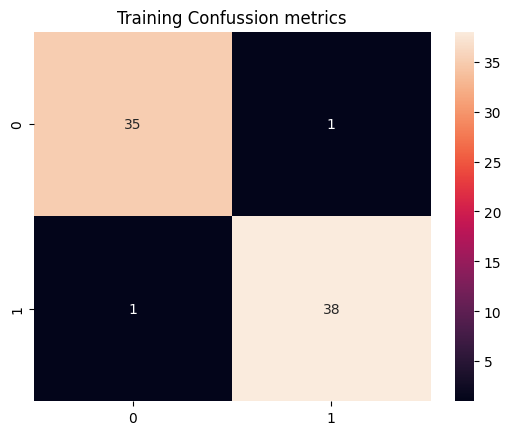

In [20]:
print("trainig accuracy: ",accuracy_score(iris_train_y,iris_train_pred))
plt.title("Training Confussion metrics")
sns.heatmap(confusion_matrix(iris_train_y,iris_train_pred),annot=True)

In [21]:
iris_test_pred = iris_classifier.predict(iris_test_x)

testing accuracy:  0.92


<Axes: title={'center': 'Testing Confussion metrics'}>

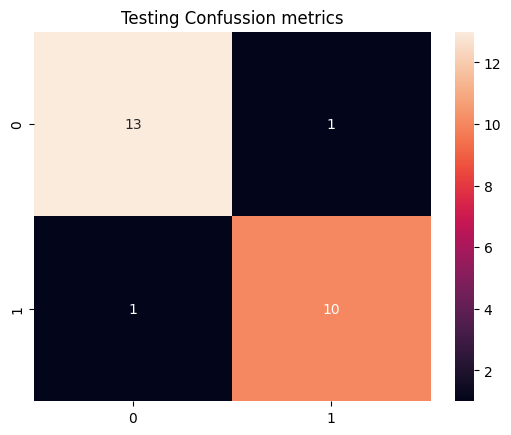

In [22]:
print("testing accuracy: ",accuracy_score(iris_test_y,iris_test_pred))
plt.title("Testing Confussion metrics")
sns.heatmap(confusion_matrix(iris_test_y,iris_test_pred),annot=True)

In [23]:
new_iris_data = pd.DataFrame([{"sepal_length":6.0 ,"sepal_width": 2.1, "petal_length":4.5, "petal_width":1.2}])

iris_classifier.predict(new_iris_data)

array([0])

<Axes: >

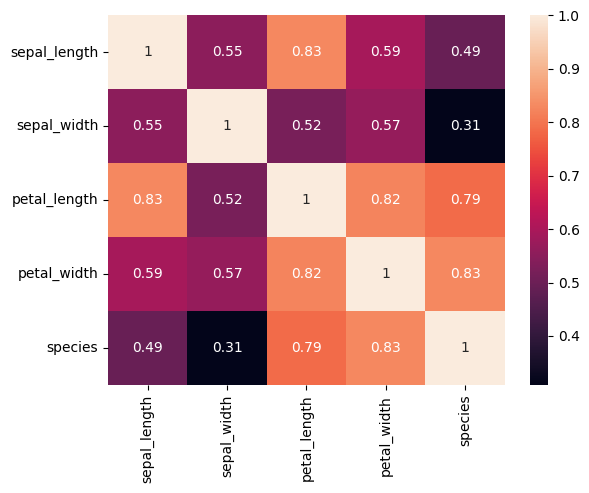

In [24]:
sns.heatmap(iris.corr(), annot=True)

In [104]:
diabities = pd.read_csv('diabetes_prediction_dataset.csv')
diabities[diabities['diabetes']==1]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
6,Female,44.0,0,0,never,19.31,6.5,200,1
26,Male,67.0,0,1,not current,27.32,6.5,200,1
38,Male,50.0,1,0,current,27.32,5.7,260,1
40,Male,73.0,0,0,former,25.91,9.0,160,1
53,Female,53.0,0,0,former,27.32,7.0,159,1
...,...,...,...,...,...,...,...,...,...
99935,Female,65.0,1,1,never,33.55,8.2,140,1
99938,Male,55.0,0,1,former,30.42,6.2,300,1
99957,Female,61.0,0,0,No Info,34.45,6.5,280,1
99962,Female,58.0,1,0,never,38.31,7.0,200,1


In [26]:
diabities.drop(['gender','smoking_history'], axis = 1, inplace= True)
d_x = diabities.iloc[:,:-1]
d_y = diabities.iloc[:,-1]
d_y.unique()

array([0, 1])

<Axes: >

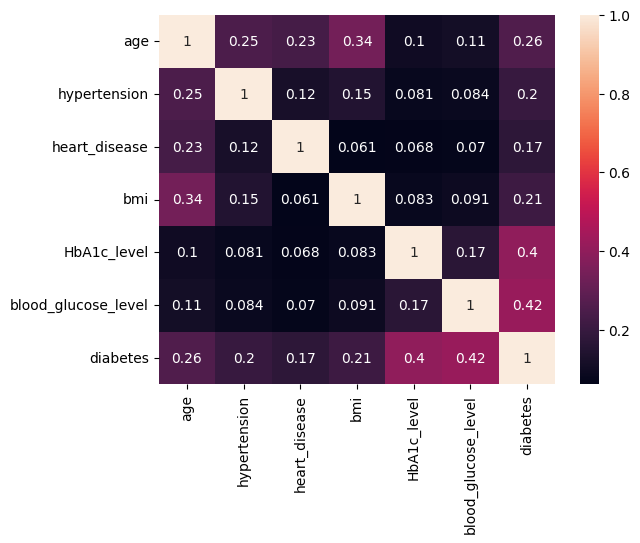

In [27]:
sns.heatmap(diabities.corr(), annot=True)

In [39]:
diabities_classifier = LogisticRegression()

In [40]:
d_train_x, d_test_x,d_train_y,d_test_y = train_test_split(d_x,d_y, test_size= 0.20, random_state= 42)

In [41]:
diabities_classifier.fit(d_train_x,d_train_y)

LogisticRegression(C=1, max_iter=200)

In [42]:
d_train_pred = diabities_classifier.predict(d_train_x)

Training Accuracy: 0.960625


<Axes: >

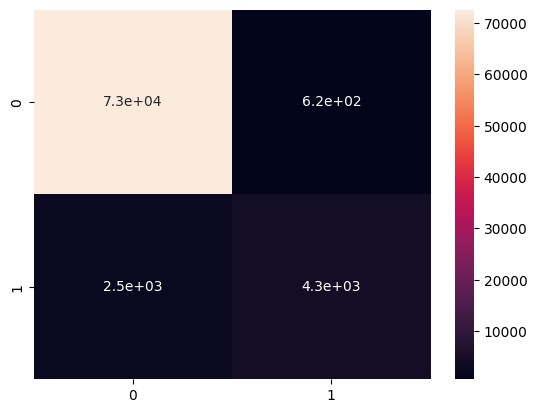

In [43]:
print("Training Accuracy:",accuracy_score(d_train_y,d_train_pred))
sns.heatmap(confusion_matrix(d_train_y,d_train_pred), annot= True)

In [44]:
d_test_pred = diabities_classifier.predict(d_test_x)

In [45]:
print("Testing Accuracy:",accuracy_score(d_test_y,d_test_pred))
confusion_matrix(d_test_y,d_test_pred)

Testing Accuracy: 0.95875


array([[18127,   165],
       [  660,  1048]])

In [91]:
d_train_x.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
75220,73.0,0,0,24.77,3.5,80
48955,80.0,0,0,24.60,5.7,145
44966,38.0,0,0,24.33,4.0,158
13568,26.0,0,0,18.87,5.0,100
92727,61.0,1,0,22.11,4.5,85


In [105]:
new_data_diabities = pd.DataFrame([{"age":40,	"hypertension":1,	"heart_disease":0,	"bmi":24,	"HbA1c_level":7.0,	"blood_glucose_level": 200}])
diabities_classifier.predict(new_data_diabities)

array([1])

In [46]:
from sklearn.model_selection import GridSearchCV

In [47]:
Parameters = {"penalty":['l1', 'l2', 'elasticnet'],
             "solver":['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
             "C":[1,2,3,4,5,6,8],
             "max_iter":[100,200,300,400,500]}

In [48]:
LoRGrid = GridSearchCV(LogisticRegression(), param_grid=Parameters, cv=5,scoring='accuracy')

In [49]:
LoRGrid.fit(d_train_x,d_train_y)

C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 8],
                         'max_iter': [100, 200, 300, 400, 500],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [50]:
LoRGrid.best_params_

{'C': 3, 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}

In [53]:
LoRGrid.best_score_

np.float64(0.9605499999999999)

In [54]:
test_pred = LoRGrid.predict(d_test_x)

In [55]:
accuracy_score(d_test_y,test_pred)

0.95875

[[18127   165]
 [  660  1048]]


<Axes: >

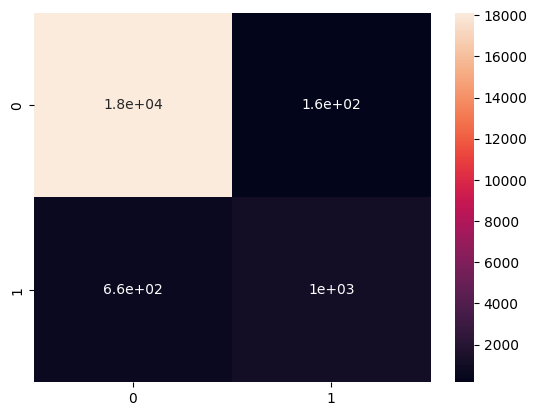

In [59]:
testing_confussion = confusion_matrix(d_test_y,test_pred)
print(testing_confussion)
sns.heatmap(testing_confussion, annot=True)

In [67]:
from sklearn.metrics import classification_report

In [68]:
print(classification_report(d_test_y, test_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.61      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [69]:
from sklearn.datasets import load_iris

In [82]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [75]:
x = pd.DataFrame(iris.data, columns = iris.feature_names)
y = pd.Series(iris.target)

In [74]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [76]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Length: 150, dtype: int64

In [77]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y, test_size=25,random_state=42)

In [78]:
iris_c = LogisticRegression(multi_class='multinomial')

In [79]:
iris_c.fit(X_train,Y_train)

C:\Users\memon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [80]:
train_pred = iris_c.predict(X_train)

In [81]:
accuracy_score(Y_train,train_pred)

0.976

In [83]:
test_pred = iris_c.predict(X_test)

In [84]:
accuracy_score(Y_test,test_pred)

1.0

<Axes: >

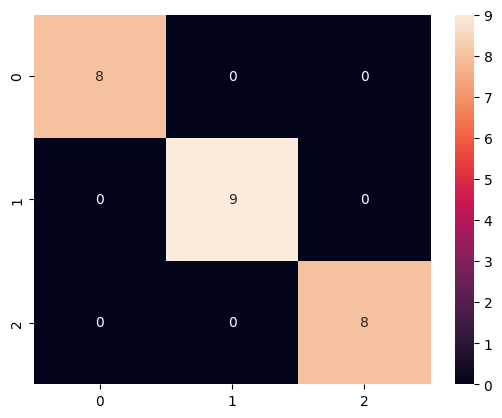

In [86]:
sns.heatmap(confusion_matrix(Y_test,test_pred), annot=True)

In [88]:
print(classification_report(Y_test,test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         8

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [90]:
new_iris_data = pd.DataFrame([{"sepal length (cm)":6.0 ,"sepal width (cm)": 2.1, "petal length (cm)":4.5, "petal width (cm)":1.2}])

iris_c.predict(new_iris_data)

array([1])